
# Principal Component Analysis (PCA): 1 PC vs 2 PCs

## Objective
Understand PCA and compare dimensionality reduction using **one principal component (1 PC)** versus **two principal components (2 PCs)**.

### Theory

**Principal Component Analysis (PCA)** is an unsupervised dimensionality-reduction technique. It transforms the original correlated features into a new set of orthogonal variables called **principal components (PCs)**.

- **PC1** captures the maximum possible variance in the data.
- **PC2** captures the maximum remaining variance while being orthogonal to PC1.
- The components are ordered by explained variance.
- PCA is usually performed after **feature standardization**, especially when features have different scales.

### 1 PC vs 2 PCs

| Aspect | 1 Principal Component | 2 Principal Components |
|---|---|---|
| Output dimensions | 1 | 2 |
| Information retained | Only variance captured by PC1 | Variance captured by PC1 + PC2 |
| Visualization | One-dimensional | Two-dimensional |
| Compression | Higher | Lower |
| Information loss | Usually higher | Usually lower |
| Best use | Very aggressive compression | Visualization and better information retention |

The percentage of information retained is measured using **explained variance ratio**:

\[
EVR_i = \frac{\lambda_i}{\sum_j \lambda_j}
\]

where \(\lambda_i\) is the eigenvalue associated with principal component \(i\).

For 1 PC:

\[
\text{Information retained} = EVR_1
\]

For 2 PCs:

\[
\text{Information retained} = EVR_1 + EVR_2
\]


## Step 1 — Import Libraries

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



## Step 2 — Load the Dataset

We use the **Wine dataset**, which contains 13 numerical features. PCA will reduce these 13 dimensions to either 1 or 2 dimensions.


In [2]:

wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

print("Original shape:", X.shape)
X.head()


Original shape: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



## Step 3 — Standardize the Features

PCA is affected by feature scale. Standardization converts each feature approximately to mean 0 and standard deviation 1.

\[
z = \frac{x - \mu}{\sigma}
\]


In [3]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Mean of first 5 standardized features:")
print(X_scaled[:, :5].mean(axis=0))

print("\nStandard deviation of first 5 standardized features:")
print(X_scaled[:, :5].std(axis=0))


Mean of first 5 standardized features:
[ 7.84141790e-15  2.44498554e-16 -4.05917497e-15 -7.11041712e-17
 -2.49488320e-17]

Standard deviation of first 5 standardized features:
[1. 1. 1. 1. 1.]


## Step 4 — PCA with 1 Principal Component

In [4]:

pca_1 = PCA(n_components=1)

X_pca_1 = pca_1.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Shape after 1 PC:", X_pca_1.shape)

print("\nExplained variance ratio:")
print(pca_1.explained_variance_ratio_)

print("\nTotal variance retained:",
      pca_1.explained_variance_ratio_.sum())


Original shape: (178, 13)
Shape after 1 PC: (178, 1)

Explained variance ratio:
[0.36198848]

Total variance retained: 0.3619884809992632



### Interpretation of 1 PC

When `n_components=1`, all 13 original features are represented by a **single value per observation**.

This gives maximum compression, but information represented by PC2, PC3, etc. is discarded.

If PC1 explains, for example, 36% of the variance, then the 1-PC representation retains approximately 36% of the total variation in the standardized dataset.


## Step 5 — PCA with 2 Principal Components

In [5]:

pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Shape after 2 PCs:", X_pca_2.shape)

print("\nExplained variance ratio:")
print(pca_2.explained_variance_ratio_)

print("\nTotal variance retained:",
      pca_2.explained_variance_ratio_.sum())


Original shape: (178, 13)
Shape after 2 PCs: (178, 2)

Explained variance ratio:
[0.36198848 0.1920749 ]

Total variance retained: 0.5540633835693529



### Interpretation of 2 PCs

With `n_components=2`, every observation is represented using **two values: PC1 and PC2**.

Because PC2 captures additional variance not captured by PC1, the total explained variance is higher than with 1 PC.

The major advantage is that the transformed data can be plotted on a 2D graph.


## Step 6 — Direct Comparison

In [6]:

comparison = pd.DataFrame({
    "Method": ["1 PC", "2 PCs"],
    "Number of Components": [1, 2],
    "Variance Retained": [
        pca_1.explained_variance_ratio_.sum(),
        pca_2.explained_variance_ratio_.sum()
    ]
})

comparison["Variance Retained (%)"] = comparison["Variance Retained"] * 100

comparison


,Method,Number of Components,Variance Retained,Variance Retained (%)
0,1 PC,1,0.361988,36.198848
1,2 PCs,2,0.554063,55.406338



## Step 7 — Visualize the 1-PC Representation

A 1-PC representation is one-dimensional, so we can visualize observations along a single horizontal axis.


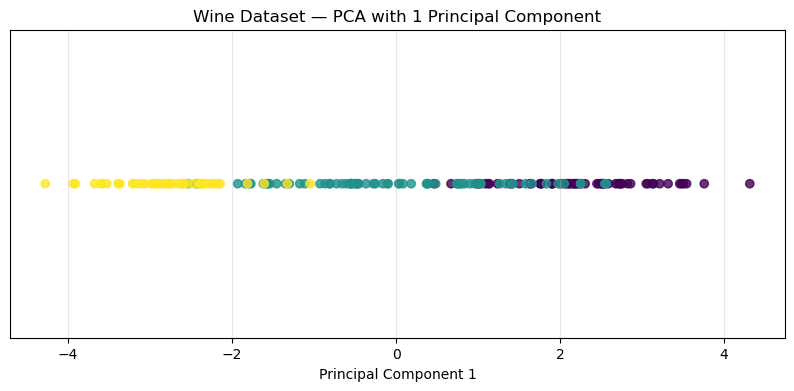

In [7]:

plt.figure(figsize=(10, 4))

plt.scatter(
    X_pca_1[:, 0],
    np.zeros(len(X_pca_1)),
    c=y,
    cmap="viridis",
    alpha=0.8
)

plt.xlabel("Principal Component 1")
plt.yticks([])
plt.title("Wine Dataset — PCA with 1 Principal Component")
plt.grid(True, alpha=0.3)
plt.show()


## Step 8 — Visualize the 2-PC Representation

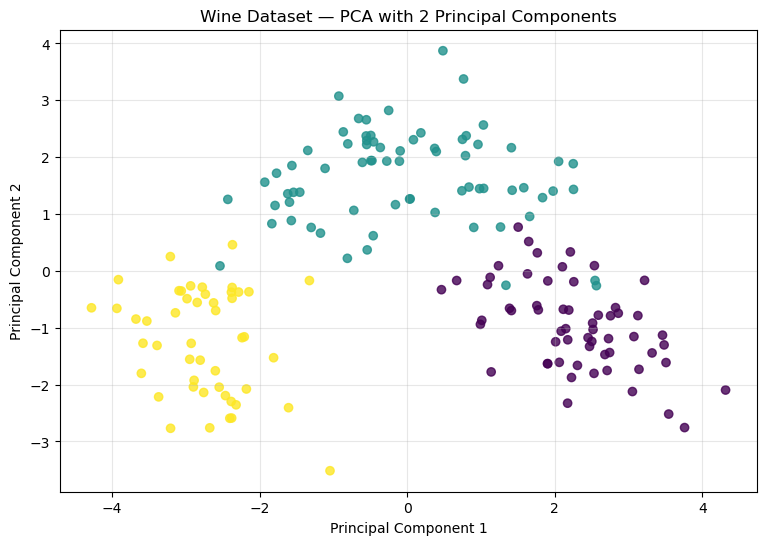

In [8]:

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    c=y,
    cmap="viridis",
    alpha=0.8
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Wine Dataset — PCA with 2 Principal Components")
plt.grid(True, alpha=0.3)
plt.show()



## Step 9 — Compare Explained Variance

A scree-style plot shows how much variance each principal component explains.


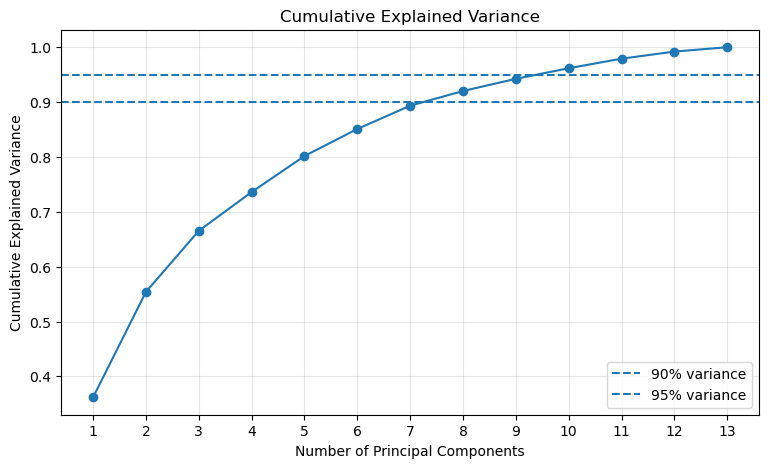

In [9]:

pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(explained) + 1),
    cumulative,
    marker="o"
)

plt.axhline(0.90, linestyle="--", label="90% variance")
plt.axhline(0.95, linestyle="--", label="95% variance")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.xticks(range(1, len(explained) + 1))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



## Step 10 — Final Theoretical Comparison

### Using 1 PC
- Reduces the original 13-dimensional data to 1 dimension.
- Provides maximum compression.
- Keeps only the variance represented by PC1.
- Easier to store and process.
- Can cause substantial information loss.
- Not suitable when PC1 alone does not explain enough variance.

### Using 2 PCs
- Reduces 13 dimensions to 2 dimensions.
- Retains PC1 and PC2.
- Preserves more information than 1 PC.
- Enables meaningful 2D visualization.
- Usually provides a better representation for exploratory analysis.
- Still removes information contained in PC3 and later components.

### Key conclusion

**1 PC = stronger dimensionality reduction but more information loss.**

**2 PCs = slightly less compression but better information retention and 2D visualization.**

The choice should not be based only on the number of components. It should be based on the **cumulative explained variance** required for the application.



## Important PCA Concepts

1. **Standardization** — puts features on a comparable scale.
2. **Covariance/correlation structure** — PCA finds directions of maximum variation.
3. **Eigenvectors** — determine the directions of the principal components.
4. **Eigenvalues** — indicate how much variance each component captures.
5. **Explained variance ratio** — tells the proportion of total variance captured.
6. **Orthogonality** — principal components are mutually perpendicular.
7. **Dimensionality reduction** — fewer components represent the original data.
8. **Reconstruction error** — information is lost when discarded components are removed.
